In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

t = np.linspace(0, 200, 10000)
z1 = np.linspace(0, 50, 5000)
z2_phys = np.linspace(50, 150, 10000)


alpha = 1.74 
Da = 1
lambda_ = np.sqrt(alpha/Da)
kappa = 1.42*10**(-2)
u1=10**(-2)+3.6*10**5
u2=0.1

In [5]:
# ── B1 ──────────────────────────────────────────────────────────────────────
def B_func51(z, t_val, u1, alpha, lambda_, kappa):
    a  = kappa - lambda_ * u1
    b_ss  = (alpha / a) * np.exp(-lambda_ * z) * (1 - np.exp(-a * z / u1))
    b_tr  = (alpha / a) * np.exp(-lambda_ * z) * (1 - np.exp(-a * t_val))
    return np.where(z <= u1 * t_val, b_ss, b_tr)


# ── B1 evaluated exactly at z = 50 ──────────────────────────────────────────
def B1_at_50(t_array, u1, alpha, lambda_, kappa):
    """Simply evaluate B_func51 at z=50 for each t — no clamp."""
    return B_func51(50.0, t_array, u1, alpha, lambda_, kappa)


# ── Interface ODE — convolution integral ─────────────────────────────────────
def interface_M(t_array, u1, u2, alpha, lambda_, kappa):
    """
    M(t) = ∫₀ᵗ  u1 · B1(50, τ) · exp(−u2·(t−τ))  dτ

    Computed incrementally so we only do O(N) work instead of O(N²).
    Update rule (trapezoidal, step by step):
        M(t_{n+1}) = M(t_n)·exp(−u2·Δt)
                   + Δt·u1·½·[B1(50,t_n)·exp(−u2·Δt) + B1(50,t_{n+1})]
    This is the exact integral assuming B1 is linear between steps.
    """
    t_array = np.asarray(t_array)
    M       = np.zeros_like(t_array)
    B1_vals = B1_at_50(t_array, u1, alpha, lambda_, kappa)
    print("These are the B1 vals: ", B1_vals, "This is the length: ", len(B1_vals))

    for i in range(1, len(t_array)):
        dt_i   = t_array[i] - t_array[i - 1]
        decay  = np.exp(-u2 * dt_i)
        # trapezoidal on the integrand f(τ) = u1·B1(50,τ) between t_{i-1} and t_i
        f_prev = u1 * B1_vals[i - 1]
        f_curr = u1 * B1_vals[i]
        M[i]   = M[i - 1] * decay + dt_i * 0.5 * (f_prev * decay + f_curr)

    return M


# ── B2 ──────────────────────────────────────────────────────────────────────
def B_func52(z2_phys, t_val, u2, alpha, lambda_, t_array, kappa, M_vals):
    a2 = kappa - lambda_ * u2
    z2 = z2_phys - 50.0        # shifted coordinate (0 at interface)

    # Characteristic travel time from interface to z
    tau_travel = z2 / u2

    # Retarded time (clipped to [0, t_val] and to array bounds)
    tau = np.clip(t_val - tau_travel, 0.0, t_array[-1])

    # M interpolated at the retarded time
    M_tau = np.interp(tau, t_array, M_vals)

    # Branch 1: characteristic has arrived (z2 ≤ u2·t_val)
    b1 = ( (alpha / a2) * np.exp(-lambda_ * z2_phys)
           + (M_tau - (alpha / a2) * np.exp(-lambda_ * 50.0))
             * np.exp(-kappa * tau_travel) )

    # Branch 2: characteristic has not yet arrived
    b2 = (alpha / a2) * np.exp(-lambda_ * z2_phys) * (1.0 - np.exp(-a2 * t_val))

    return np.where(z2 <= u2 * t_val, b1, b2)

These are the B1 vals:  [-0.00000000e+00  3.66413333e-06  3.66413333e-06 ...  3.66413333e-06
  3.66413333e-06  3.66413333e-06] This is the length:  10000
max value: -0.0 time 0.00
max value: 11.759985019296359 time 22.22
max value: 13.035820961544864 time 44.44
max value: 13.174080780561821 time 66.67
max value: 13.189063723839483 time 88.89
max value: 13.190687395784545 time 111.11
max value: 13.190863349903708 time 133.33
max value: 13.190882417703905 time 155.56
max value: 13.190884484043725 time 177.78
max value: 13.190884707968893 time 200.00


C:\Users\sif\AppData\Local\Temp\ipykernel_19136\250468193.py:5: RuntimeWarning: overflow encountered in exp
  b_tr  = (alpha / a) * np.exp(-lambda_ * z) * (1 - np.exp(-a * t_val))


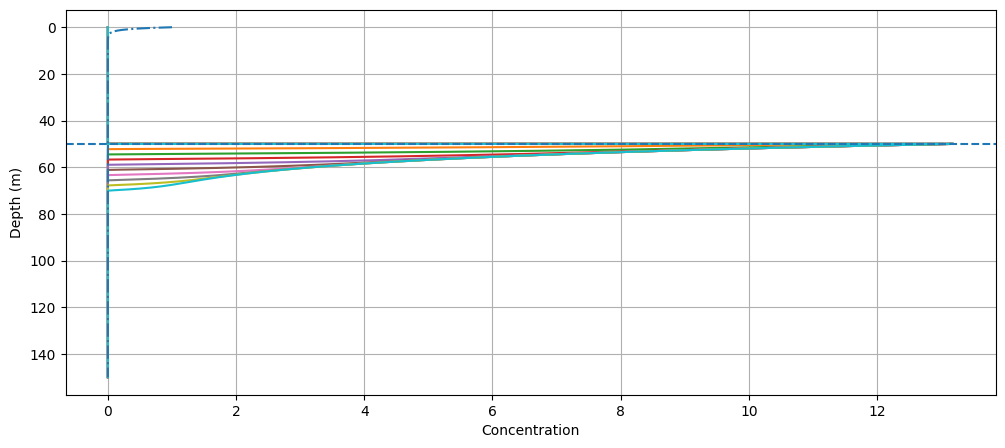

In [ ]:

z= np.linspace(0, 150, 15000)

# A steady state
A = np.exp(-lambda_*z)
# mass exchange at the interface
M_vals = interface_M(t, u1, u2, alpha, lambda_, kappa)


indices = np.linspace(0, len(t) - 1, 10, dtype=int)
t_sampled = t[indices]
plt.figure(figsize=(12, 5))
for i in range(len(t_sampled)):
    ti = t_sampled[i]

    B1 = B_func51(z1, ti, u1, alpha, lambda_, kappa)
    B2 = B_func52(z2_phys, ti, u2, alpha, lambda_, t, kappa, M_vals)
    B = np.concatenate((B1, B2))

    plt.plot(B,z, label=f"t={ti:.2f} years")


    print("max value:", np.max(B), "time", f"{ti:.2f}")
    #print("initial condition:", B)
    #plt.plot(z, B, label=f"t={t[i]:.2f} years")
    #print("maximal value:", np.max(B[:]), "time",f"t={t_sampled[i]:.2f} years")
#plt.plot(z, A, label="A Steady state", linestyle='--')
plt.ylabel("Depth (m)")
plt.plot( A,z,label="A", linestyle='-.')
plt.xlabel("Concentration")
plt.axhline(y=50, linestyle='--',label="Seabed")
plt.gca().invert_yaxis()
plt.legend()
plt.grid()